In [1]:
from __future__ import annotations

%load_ext jupyter_black

%load_ext autoreload
%autoreload 2

import os
import sys

if os.getcwd().endswith("/notebooks"):  # if the notebook has been moved to the notebooks directory
    sys.path.append(os.pardir)  # include the parent directory in the path

In [2]:
import time

import torch
import numpy as np
import pandas as pd
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from cartopy.mpl.geoaxes import GeoAxes

from torch_spa import solar_position

# assert_close


In [3]:
lats = 40
lons = -105
datetimes = ["2010-06-21 00:06:00", "2010-06-21 00:12:00"]


AZ, EL = solar_position(datetimes, lats, lons).squeeze()


torch.testing.assert_close(AZ, torch.tensor([280.3651, 281.2308]).double(), atol=1e-2, rtol=1e-2)

torch.testing.assert_close(EL, torch.tensor([25.16378, 24.03705]).double(), atol=1e-2, rtol=1e-2)

# Global Visualization

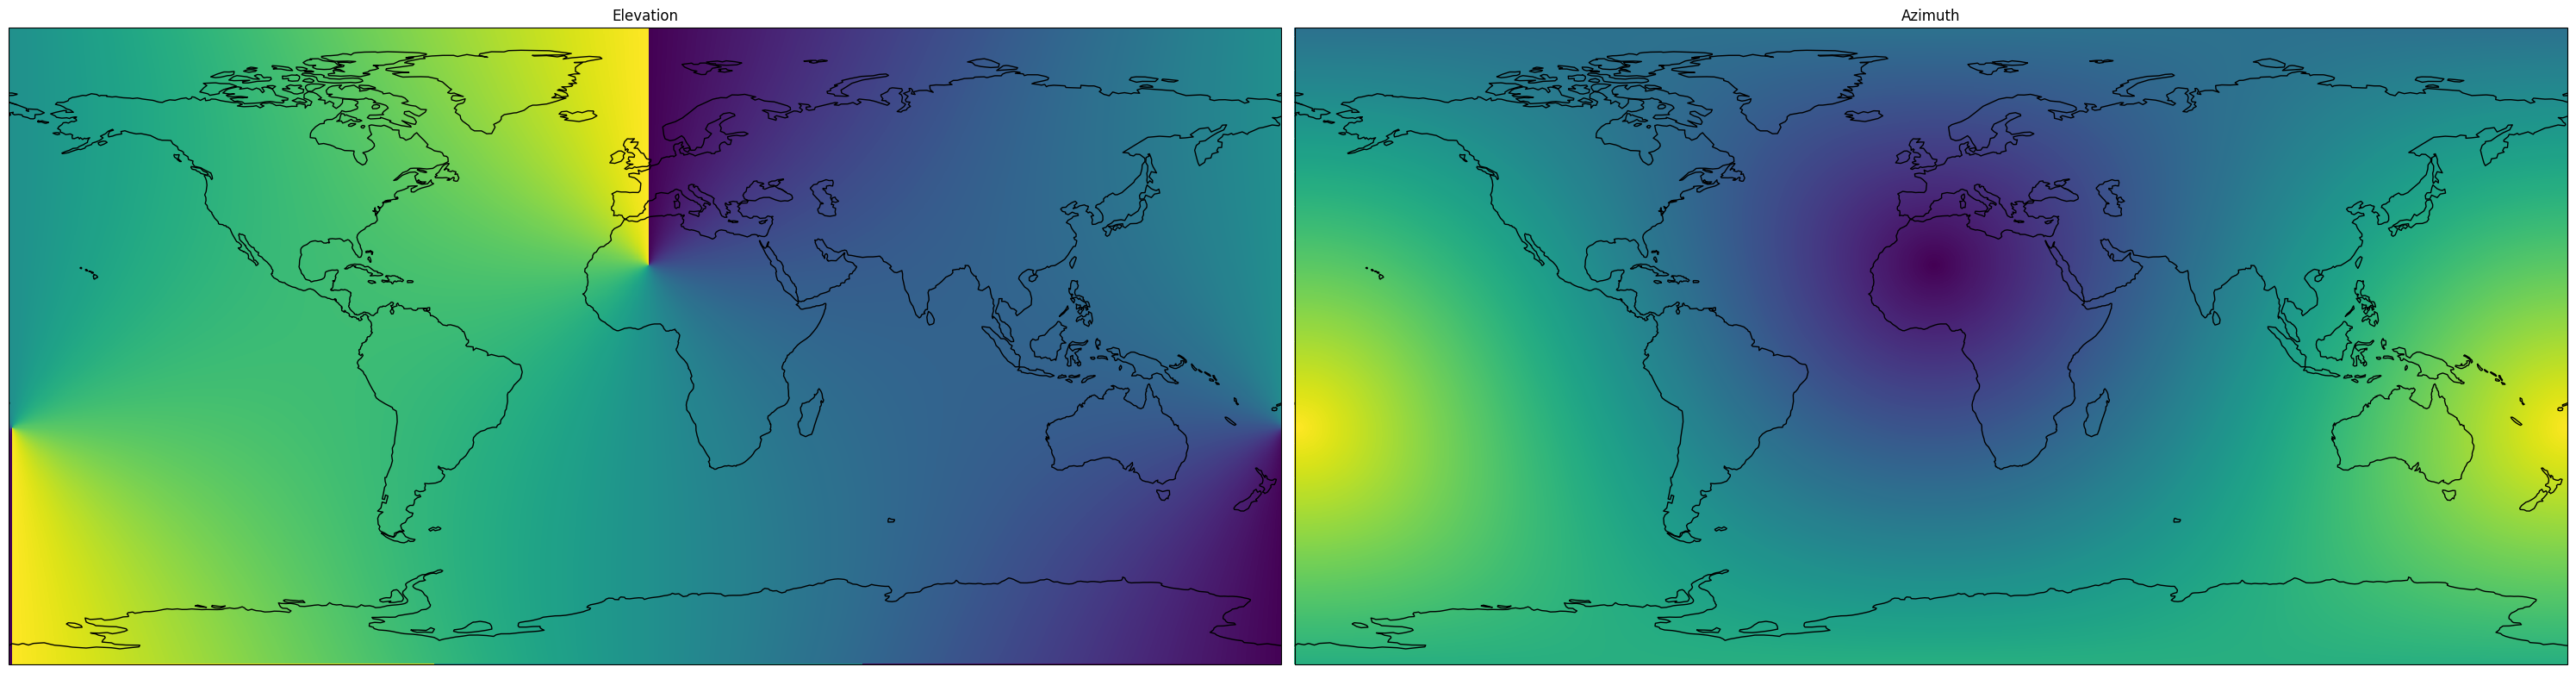

In [4]:
out_image = "assets/globe.png"
T = 5
Y = 721
X = 1440
time_index = np.array(["2010-07-01 12:00:00"], dtype=np.datetime64) + np.array(
    [np.timedelta64(i, "h") for i in range(T)]
)
lats = np.linspace(-90, 90, Y)
lons = np.linspace(-180, 180, X)
lats, lons = np.meshgrid(lats, lons, indexing="ij")


EL, AZ = solar_position(time_index, lats, lons)  # .norm()


fig, axes = plt.subplots(1, 2, figsize=(30, 10), subplot_kw={"projection": ccrs.PlateCarree()})
fig.tight_layout()
axes = axes.flatten()
ax: GeoAxes

ax = axes[0]
ax.pcolormesh(lons, lats, EL[0].detach().numpy())
ax.coastlines()
ax.set_title("Elevation")

ax = axes[1]
ax.pcolormesh(lons, lats, AZ[0].detach().numpy())
ax.coastlines()
ax.set_title("Azimuth")


if not os.path.exists(out_image):
    fig.savefig(out_image)

# NOAA Solar Calculator Comparison

time taken:  0.0015826225280761719


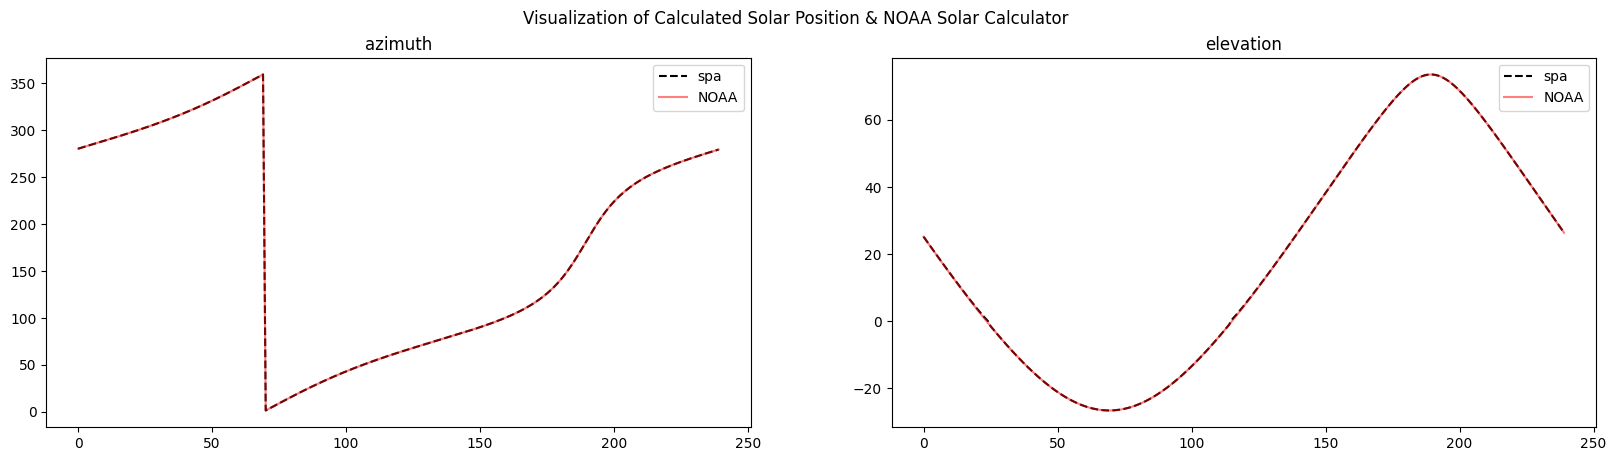

In [5]:
out_image = "assets/chart.png"
ax: plt.Axes  # type: ignore
test_file = "assets/NOAA_Solar_Calculations_day.csv"
# the csv test file was generated by the NOAA Solar Calculator
# using the following parameters:
lats = 40
lons = -105

df = pd.read_csv(test_file, index_col=0)
# df.index = pd.to_datetime(df['Date'] + " " + df['Time (past local midnight)']) # type: ignore
test_azimuth = df["Solar Azimuth Angle (deg cw from N)"].to_numpy()
test_elev = df["Solar Elevation Angle (deg)"].to_numpy()
datetimes = pd.to_datetime(df["Date"] + " " + df["Time (past local midnight)"])

start = time.time()
data = solar_position(datetimes, lats, lons)
end = time.time()
print("time taken: ", end - start)
AZ = data.azimuth.squeeze()
EL = data.elevation.squeeze()
# plotting a comparison of the calculated solar position and the NOAA Solar Calculator Output
fig, axes = plt.subplots(1, 2)
fig.suptitle("Visualization of Calculated Solar Position & NOAA Solar Calculator")
fig.set_figwidth(20)

# azimuth
ax = axes[0]
ax.plot(AZ, label="spa", c="k", ls="--")
ax.plot(test_azimuth, label="NOAA", c="r", ls="-", alpha=0.5)
ax.set_title("azimuth")
ax.legend()
np.testing.assert_allclose(AZ, test_azimuth, atol=0.1)

# elevation
ax = axes[1]
ax.plot(EL, label="spa", c="k", ls="--")
ax.plot(test_elev, label="NOAA", c="r", ls="-", alpha=0.5)
ax.set_title("elevation")
ax.legend()
np.testing.assert_allclose(EL, test_elev, atol=0.75)


if not os.path.exists(out_image):
    fig.savefig(out_image)